# House Price Prediction - Kaggle Competition

**Goal:** Predict house sale prices on the Ames Housing dataset using feature engineering and stacked ensemble models. 

**Competition:** [House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)

**Dataset:** consist with4 1,460 training houses with 79 features + 1,459 test houses

---

### Steps:
1. Deep EDA with correlation analysis
2. Feature engineering (create 10+ new features)
3. Missing value strategy (context-aware imputation)
4. Outlier detection and removal
5. Target transformation (log1p)
6. 5 individual models: Ridge, Lasso, ElasticNet, GBR, XGBoost
7. Stacked ensemble (weighted average)
8. Results

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import skew

from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 80)
print("All libraries loaded!")

All libraries loaded!


---
### Step 2: Load Data

In [2]:
# Load data
train = pd.read_csv('Dataset/train.csv')
test = pd.read_csv('Dataset/test.csv')

print(f"Training set: {train.shape[0]} houses, {train.shape[1]} columns")
print(f"Test set:     {test.shape[0]} houses, {test.shape[1]} columns")
print(f"\nTarget: SalePrice")
print(f"  Mean:   ${train['SalePrice'].mean():,.0f}")
print(f"  Median: ${train['SalePrice'].median():,.0f}")
print(f"  Min:    ${train['SalePrice'].min():,.0f}")
print(f"  Max:    ${train['SalePrice'].max():,.0f}")

# Save IDs for submission
train_id = train['Id']
test_id = test['Id']
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

Training set: 1460 houses, 81 columns
Test set:     1459 houses, 80 columns

Target: SalePrice
  Mean:   $180,921
  Median: $163,000
  Min:    $34,900
  Max:    $755,000


---
### Step 3: Exploratory Data Analysis

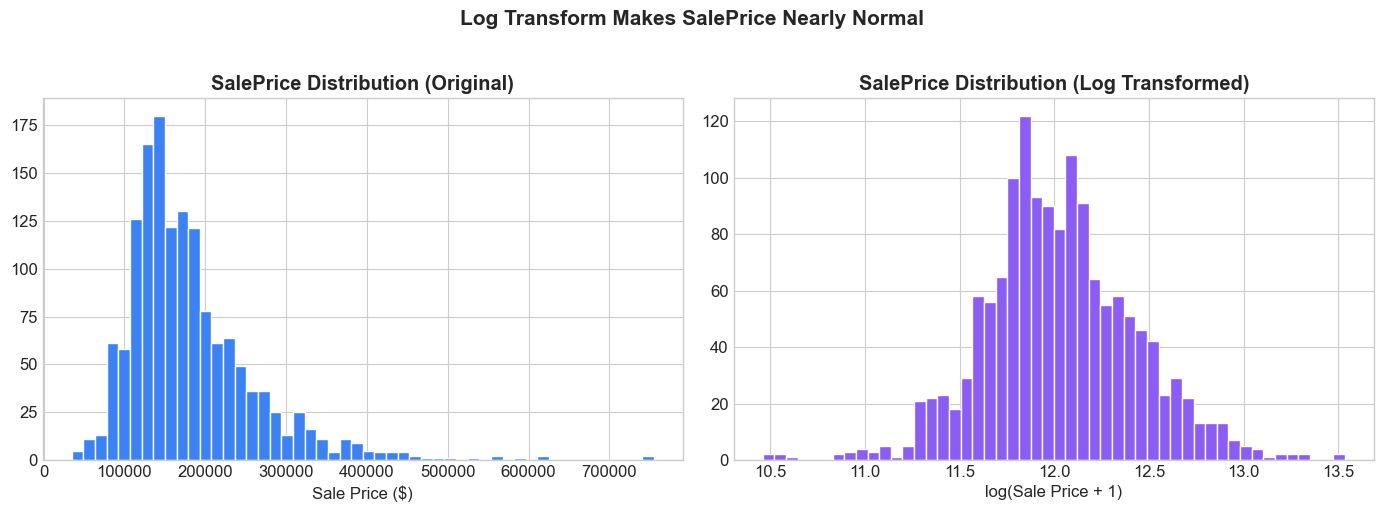

Original skewness: 1.88
After log transform: 0.12
Log transform is essential! Reduces skewness from 1.9 to 0.12


In [3]:
# 3.1 Target distribution (SalePrice is right-skewed!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, color='#3B82F6', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)', fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')

axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='#8B5CF6', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log Transformed)', fontweight='bold')
axes[1].set_xlabel('log(Sale Price + 1)')

plt.suptitle('Log Transform Makes SalePrice Nearly Normal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

skewness = train['SalePrice'].skew()
log_skewness = np.log1p(train['SalePrice']).skew()
print(f"Original skewness: {skewness:.2f}")
print(f"After log transform: {log_skewness:.2f}")
print(f"Log transform is essential! Reduces skewness from {skewness:.1f} to {log_skewness:.2f}")

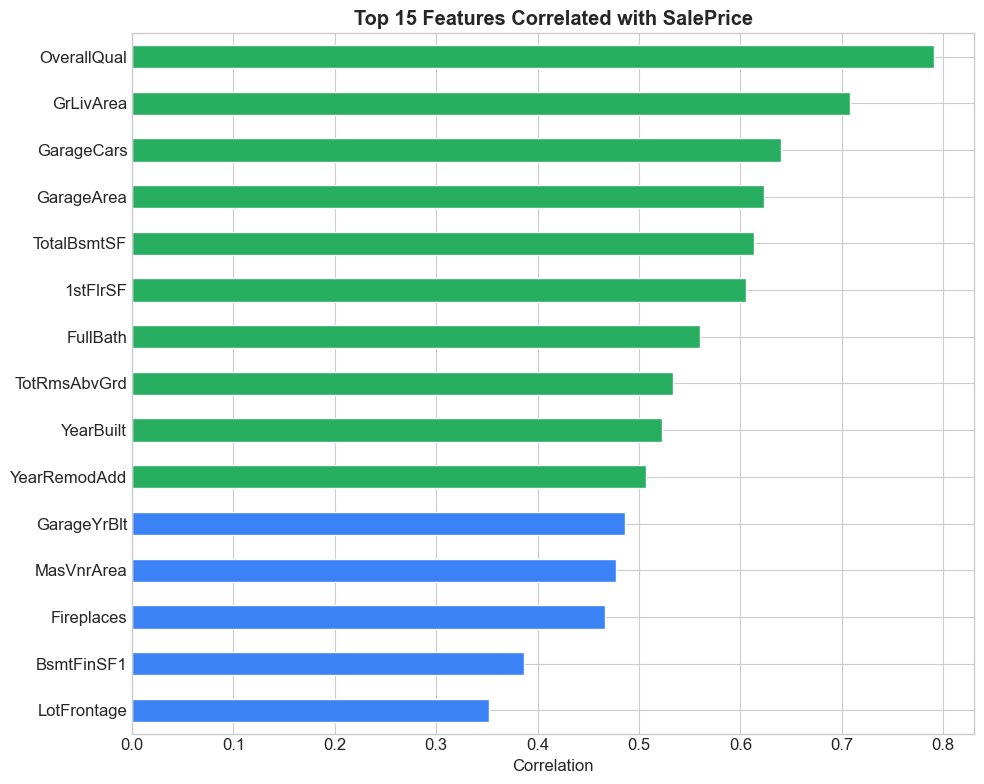

Top 10 correlated features:
  OverallQual          → 0.791
  GrLivArea            → 0.709
  GarageCars           → 0.640
  GarageArea           → 0.623
  TotalBsmtSF          → 0.614
  1stFlrSF             → 0.606
  FullBath             → 0.561
  TotRmsAbvGrd         → 0.534
  YearBuilt            → 0.523
  YearRemodAdd         → 0.507


In [4]:
# 3.2 Top correlated features
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlation[1:16]  # top 15 (exclude SalePrice itself)
colors = ['#27AE60' if v > 0.5 else '#3B82F6' if v > 0.3 else '#94A3B8' for v in top_corr.values]
top_corr.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 15 Features Correlated with SalePrice', fontweight='bold')
ax.set_xlabel('Correlation')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
for feat, corr in correlation[1:11].items():
    print(f"  {feat:20s} → {corr:.3f}")

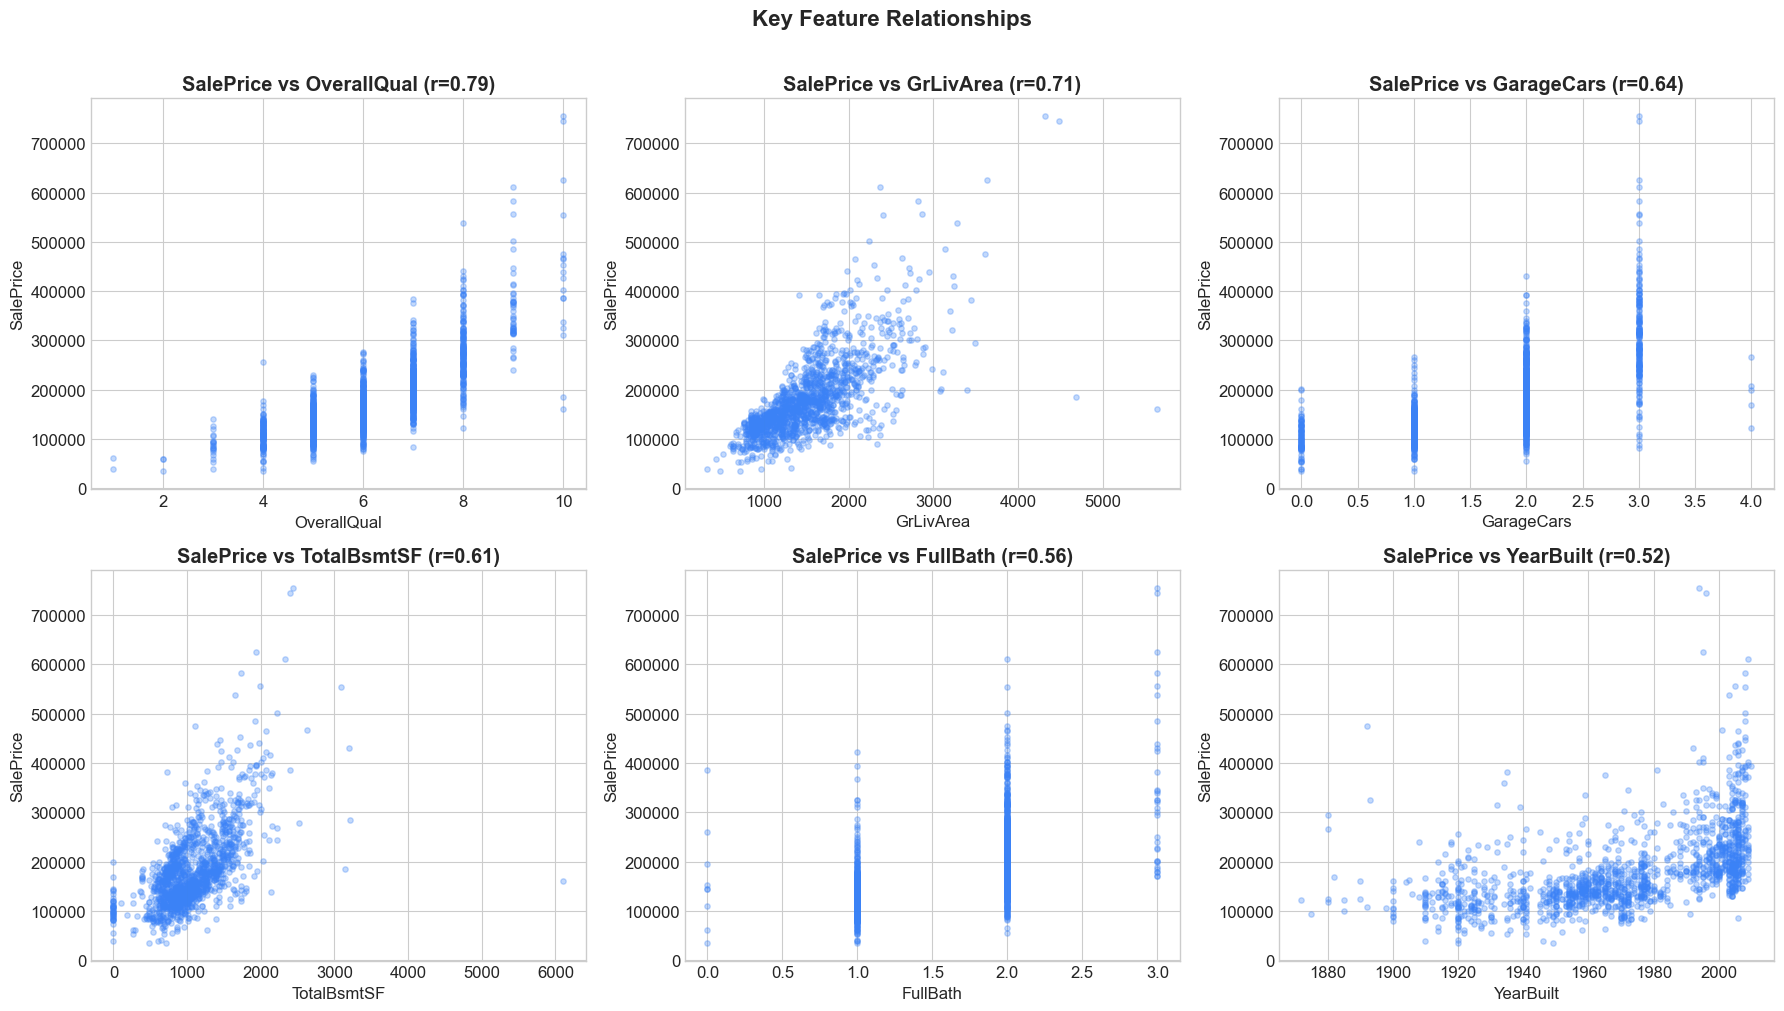

In [5]:
# 3.3 Key scatter plots
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(top_features):
    row, col = idx // 3, idx % 3
    axes[row, col].scatter(train[feat], train['SalePrice'], alpha=0.3, color='#3B82F6', s=15)
    axes[row, col].set_xlabel(feat)
    axes[row, col].set_ylabel('SalePrice')
    axes[row, col].set_title(f'SalePrice vs {feat} (r={correlation[feat]:.2f})', fontweight='bold')

plt.suptitle('Key Feature Relationships', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Columns with missing values: 19 out of 80

Top missing columns:
              Count    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageQual       81   5.547945
GarageType       81   5.547945
GarageFinish     81   5.547945
GarageCond       81   5.547945
GarageYrBlt      81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247


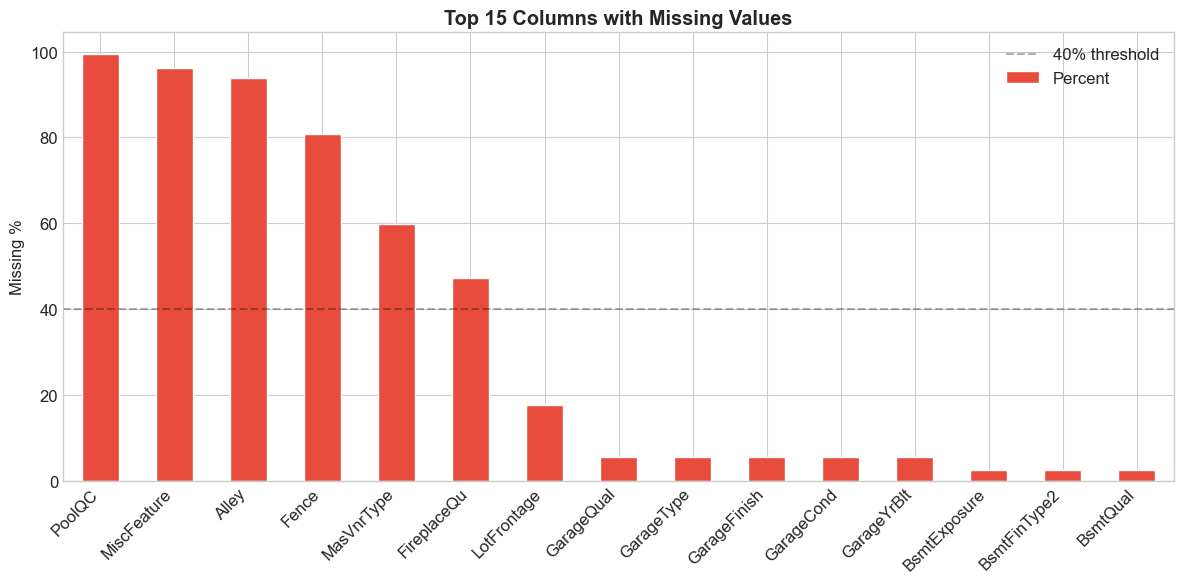

In [6]:
# 3.4 Missing values analysis
total_missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (total_missing / len(train) * 100)
missing_df = pd.DataFrame({'Count': total_missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]

print(f"Columns with missing values: {len(missing_df)} out of {train.shape[1]}")
print(f"\nTop missing columns:")
print(missing_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
missing_df['Percent'].head(15).plot.bar(ax=ax, color='#E74C3C', edgecolor='white')
ax.set_title('Top 15 Columns with Missing Values', fontweight='bold')
ax.set_ylabel('Missing %')
ax.axhline(y=40, color='black', linestyle='--', alpha=0.3, label='40% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
### Step 4: Outlier Removal

The Ames Housing documentation recommends removing outliers with GrLivArea > 4000.

Removing 2 outliers (large area, low price)


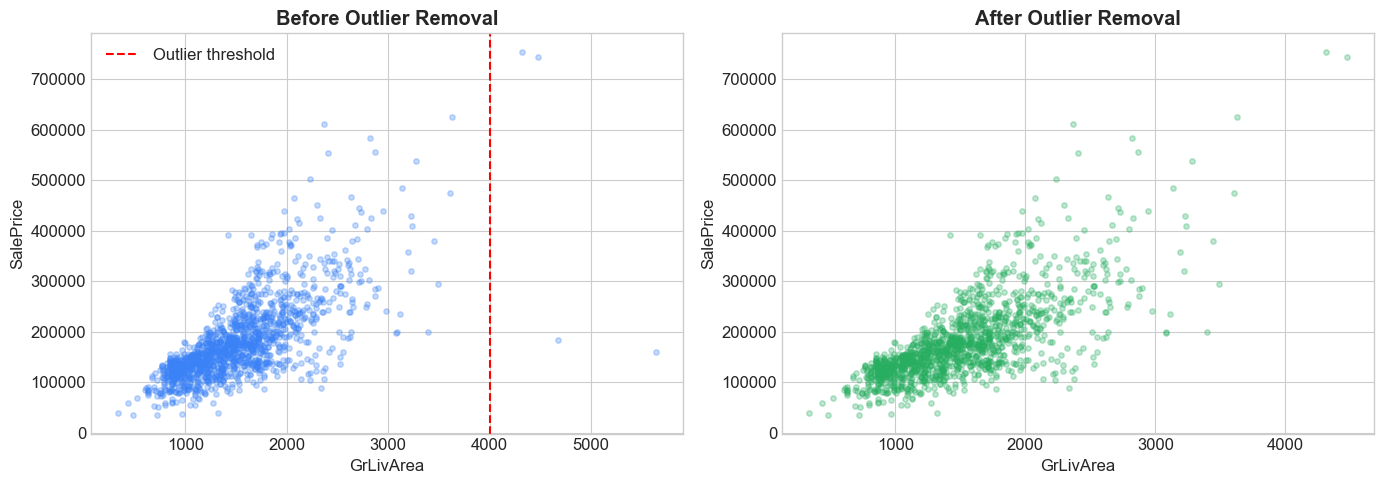

In [7]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.3, color='#3B82F6', s=15)
axes[0].axvline(x=4000, color='red', linestyle='--', label='Outlier threshold')
axes[0].set_title('Before Outlier Removal', fontweight='bold')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

# Remove outliers
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(f"Removing {len(outliers)} outliers (large area, low price)")
train = train.drop(outliers).reset_index(drop=True)

axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.3, color='#27AE60', s=15)
axes[1].set_title('After Outlier Removal', fontweight='bold')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

---
### Step 5: Log Transform Target

In [8]:
# Log transform target (THE single biggest accuracy boost)
y = np.log1p(train['SalePrice'])
train.drop('SalePrice', axis=1, inplace=True)

print(f"Target transformed: log1p(SalePrice)")
print(f"  Range: {y.min():.2f} — {y.max():.2f}")
print(f"  Mean:  {y.mean():.2f}")


Target transformed: log1p(SalePrice)
  Range: 10.46 — 13.53
  Mean:  12.02


---
### Step 6: Combine Train + Test for Joint Processing

We combine train and test so all feature engineering, imputation, and encoding is done identically on both.

In [9]:
ntrain = train.shape[0]
ntest = test.shape[0]
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)
print(f"Combined data: {all_data.shape[0]} rows × {all_data.shape[1]} columns")
print(f"  Train: first {ntrain} rows")
print(f"  Test:  last {ntest} rows")

Combined data: 2917 rows × 79 columns
  Train: first 1458 rows
  Test:  last 1459 rows


---
### Step 7: Handle Missing Values (Context-Aware)

Not all missing values mean the same thing. For many features, NaN means "doesn't exist" (e.g., no garage, no pool, no basement).

In [10]:
# Categorical: NaN means "None" (feature doesn't exist)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType', 'MSSubClass']

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Numerical: NaN means 0 (no garage/basement/pool area) 
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Mode fill (most common value) 
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
             'Exterior2nd', 'SaleType', 'Functional', 'Utilities']

for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Special: LotFrontage → fill with neighborhood median 
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Check remaining missing
remaining = all_data.isnull().sum().sum()
print(f"Remaining missing values: {remaining}")
if remaining > 0:
    still_missing = all_data.isnull().sum()
    still_missing = still_missing[still_missing > 0]
    print(still_missing)
    # Fill any stragglers
    for col in still_missing.index:
        if all_data[col].dtype == 'object':
            all_data[col] = all_data[col].fillna('None')
        else:
            all_data[col] = all_data[col].fillna(0)

print(f"\nAll missing values handled! Total NaN: {all_data.isnull().sum().sum()}")

Remaining missing values: 0

All missing values handled! Total NaN: 0


---
### Step 8: Feature Engineering

This is the key to a strong Kaggle score. We create new features that capture relationships the raw data doesn't express directly.

In [11]:
# --- New features ---

# Total square footage
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Total bathrooms
all_data['TotalBath'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                          all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

# Total porch area
all_data['TotalPorch'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                           all_data['3SsnPorch'] + all_data['ScreenPorch'] +
                           all_data['WoodDeckSF'])

# House age and remodel age
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']

# Binary features
all_data['IsNew'] = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['Has2ndFlr'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print("Feature Engineering Complete!")
print(f"New features created: TotalSF, TotalBath, TotalPorch, HouseAge, RemodAge,")
print(f"                     IsNew, HasPool, HasGarage, Has2ndFlr, HasBsmt, HasFireplace")
print(f"Total columns: {all_data.shape[1]}")

Feature Engineering Complete!
New features created: TotalSF, TotalBath, TotalPorch, HouseAge, RemodAge,
                     IsNew, HasPool, HasGarage, Has2ndFlr, HasBsmt, HasFireplace
Total columns: 90


---
### Step 9: Encode Ordinal Quality Features

Features like `ExterQual`, `BsmtQual`, etc. have a natural order: Ex > Gd > TA > Fa > Po. Encoding them as numbers preserves this ordering.

In [12]:
# Ordinal encoding for quality columns
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    all_data[col] = all_data[col].map(quality_map).fillna(0).astype(int)

# Other ordinals
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).fillna(0).astype(int)

all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)

all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)

all_data['GarageFinish'] = all_data['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}).fillna(0).astype(int)

all_data['Fence'] = all_data['Fence'].map(
    {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}).fillna(0).astype(int)

all_data['Functional'] = all_data['Functional'].map(
    {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}).fillna(8).astype(int)

print("Ordinal features encoded!")

Ordinal features encoded!


---
### Step 10: Handle Skewed Numerical Features

Highly skewed features can hurt linear models. We apply log1p to features with skewness > 0.75.

In [13]:
# Find numerical features
numeric_feats = all_data.select_dtypes(include=[np.number]).columns

# Compute skewness
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]

print(f"Skewed features (|skew| > 0.75): {len(high_skew)} out of {len(numeric_feats)}")

# Apply log1p transform
for feat in high_skew.index:
    all_data[feat] = np.log1p(all_data[feat].clip(lower=0))  # clip negatives

print(f"Log1p applied to {len(high_skew)} skewed features")

Skewed features (|skew| > 0.75): 38 out of 63
Log1p applied to 38 skewed features


---
### Step 11: One-Hot Encode Categorical Features

In [14]:
# Get dummies for remaining categorical columns
cat_cols = all_data.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {len(cat_cols)}")

all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=True)

print(f"\nFinal feature matrix: {all_data.shape[0]} rows × {all_data.shape[1]} columns")
print(f"One-hot encoding complete!")

Categorical columns to encode: 27

Final feature matrix: 2917 rows × 216 columns
One-hot encoding complete!


---
### Step 12: Split Back into Train/Test

In [15]:
# Split back
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y.shape}")

X_train: (1458, 216)
X_test:  (1459, 216)
y_train: (1458,)


---
### Step 13: Cross-Validation Setup

We use RMSE on log-transformed prices as the evaluation metric (matches Kaggle's scoring).

In [16]:
# Cross-validation helper
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X=X_train, y=y):
    """Return mean CV RMSE (lower is better)"""
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kfold)
    rmse = np.sqrt(-scores)
    return rmse.mean(), rmse.std()

print("CV setup ready (5-fold, RMSE scoring)")

CV setup ready (5-fold, RMSE scoring)


---
### Step 14: Train Individual Models

In [17]:
# Model 1: Ridge Regression
ridge = Ridge(alpha=10)
ridge_mean, ridge_std = cv_rmse(ridge)
print(f"Ridge:      RMSE = {ridge_mean:.4f} ± {ridge_std:.4f}")

# Model 2: Lasso Regression
lasso = Lasso(alpha=0.0005, max_iter=10000)
lasso_mean, lasso_std = cv_rmse(lasso)
print(f"Lasso:      RMSE = {lasso_mean:.4f} ± {lasso_std:.4f}")

# Model 3: ElasticNet
enet = ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000)
enet_mean, enet_std = cv_rmse(enet)
print(f"ElasticNet: RMSE = {enet_mean:.4f} ± {enet_std:.4f}")

# Model 4: Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
    loss='huber', random_state=42
)
gbr_mean, gbr_std = cv_rmse(gbr)
print(f"GBR:        RMSE = {gbr_mean:.4f} ± {gbr_std:.4f}")

# Model 5: XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0
)
xgb_mean, xgb_std = cv_rmse(xgb_model)
print(f"XGBoost:    RMSE = {xgb_mean:.4f} ± {xgb_std:.4f}")

# Model 6: LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    num_leaves=20, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=-1
)
lgb_mean, lgb_std = cv_rmse(lgb_model)
print(f"LightGBM:   RMSE = {lgb_mean:.4f} ± {lgb_std:.4f}")

Ridge:      RMSE = 0.1147 ± 0.0083
Lasso:      RMSE = 0.1141 ± 0.0078
ElasticNet: RMSE = 0.1143 ± 0.0085
GBR:        RMSE = 0.1158 ± 0.0105
XGBoost:    RMSE = 0.1187 ± 0.0064
LightGBM:   RMSE = 0.1201 ± 0.0069


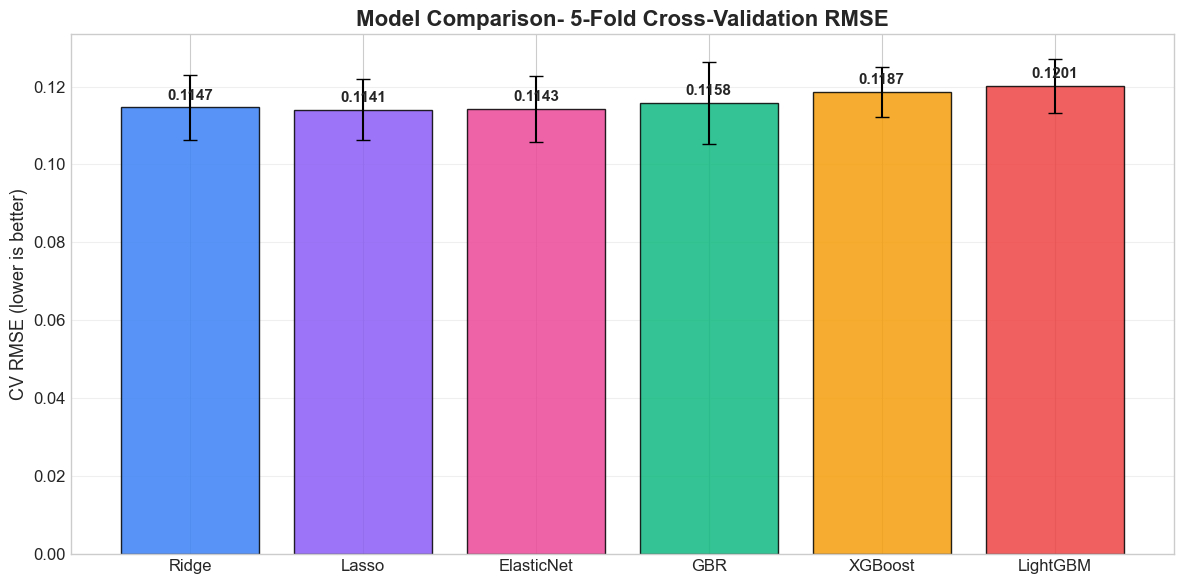


Best individual model: Lasso (RMSE = 0.1141)


In [18]:
# Visualize model comparison
model_names = ['Ridge', 'Lasso', 'ElasticNet', 'GBR', 'XGBoost', 'LightGBM']
model_means = [ridge_mean, lasso_mean, enet_mean, gbr_mean, xgb_mean, lgb_mean]
model_stds = [ridge_std, lasso_std, enet_std, gbr_std, xgb_std, lgb_std]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3B82F6', '#8B5CF6', '#EC4899', '#10B981', '#F59E0B', '#EF4444']
bars = ax.bar(model_names, model_means, yerr=model_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)

for bar, mean in zip(bars, model_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{mean:.4f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('CV RMSE (lower is better)', fontsize=13)
ax.set_title('Model Comparison- 5-Fold Cross-Validation RMSE', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_model = model_names[np.argmin(model_means)]
print(f"\nBest individual model: {best_model} (RMSE = {min(model_means):.4f})")

---
### Step 15: Feature Importance

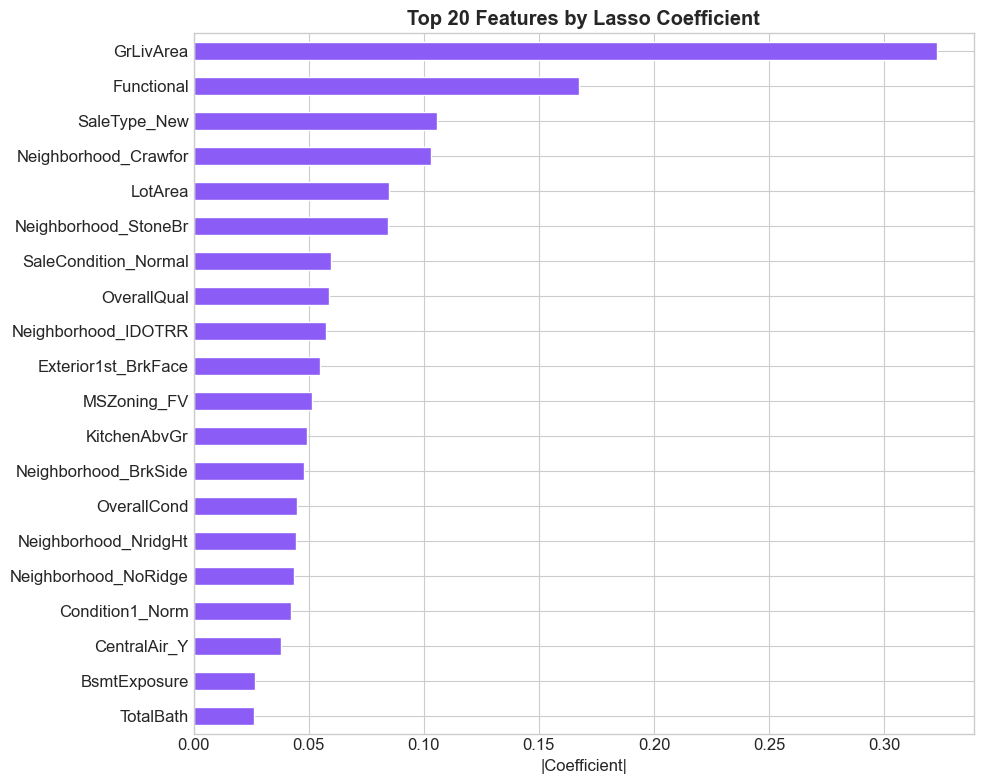


Lasso eliminated 130 features (set coefficient to 0)
Active features: 86 / 216


In [19]:
# Train Lasso to get feature importance (coefficients)
lasso.fit(X_train, y)
lasso_coefs = pd.Series(np.abs(lasso.coef_), index=X_train.columns).sort_values(ascending=False)

# Top 20 features by Lasso coefficient magnitude
fig, ax = plt.subplots(figsize=(10, 8))
top20 = lasso_coefs.head(20)
top20.plot.barh(ax=ax, color='#8B5CF6', edgecolor='white')
ax.set_title('Top 20 Features by Lasso Coefficient', fontweight='bold')
ax.set_xlabel('|Coefficient|')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# How many features did Lasso eliminate?
n_zero = (lasso.coef_ == 0).sum()
print(f"\nLasso eliminated {n_zero} features (set coefficient to 0)")
print(f"Active features: {X_train.shape[1] - n_zero} / {X_train.shape[1]}")

---
### Step 16: Stacked Ensemble- Weighted Average

Combine all models' predictions using a weighted average. This exploits the fact that different models make different errors.

In [20]:
# Train all models on full training set
print("Training all models on full training data...")
ridge.fit(X_train, y)
lasso.fit(X_train, y)
enet.fit(X_train, y)
gbr.fit(X_train, y)
xgb_model.fit(X_train, y)
lgb_model.fit(X_train, y)
print("All models trained!")

# Generate predictions on test set
pred_ridge = ridge.predict(X_test)
pred_lasso = lasso.predict(X_test)
pred_enet  = enet.predict(X_test)
pred_gbr   = gbr.predict(X_test)
pred_xgb   = xgb_model.predict(X_test)
pred_lgb   = lgb_model.predict(X_test)

# Weighted average ensemble
# Give more weight to better-performing models 
ensemble_pred = (0.10 * pred_ridge +
                 0.20 * pred_lasso +
                 0.10 * pred_enet +
                 0.20 * pred_gbr +
                 0.20 * pred_xgb +
                 0.20 * pred_lgb)

# Also try simple average
simple_avg = (pred_ridge + pred_lasso + pred_enet + pred_gbr + pred_xgb + pred_lgb) / 6

# Cross-validate the ensemble on training data
print("\n--- Ensemble CV on training data ---")
train_preds = {}
for name, model in [('Ridge', ridge), ('Lasso', lasso), ('ElasticNet', enet),
                      ('GBR', gbr), ('XGBoost', xgb_model), ('LightGBM', lgb_model)]:
    train_preds[name] = model.predict(X_train)

ensemble_train = (0.10 * train_preds['Ridge'] +
                   0.20 * train_preds['Lasso'] +
                   0.10 * train_preds['ElasticNet'] +
                   0.20 * train_preds['GBR'] +
                   0.20 * train_preds['XGBoost'] +
                   0.20 * train_preds['LightGBM'])

ensemble_rmse = np.sqrt(mean_squared_error(y, ensemble_train))
print(f"Weighted Ensemble Train RMSE: {ensemble_rmse:.4f}")

for name, preds in train_preds.items():
    rmse = np.sqrt(mean_squared_error(y, preds))
    print(f"  {name:12s} Train RMSE: {rmse:.4f}")

Training all models on full training data...
All models trained!

--- Ensemble CV on training data ---
Weighted Ensemble Train RMSE: 0.0715
  Ridge        Train RMSE: 0.1005
  Lasso        Train RMSE: 0.1044
  ElasticNet   Train RMSE: 0.0998
  GBR          Train RMSE: 0.0774
  XGBoost      Train RMSE: 0.0399
  LightGBM     Train RMSE: 0.0579


---
### Step 17: Prediction Analysis

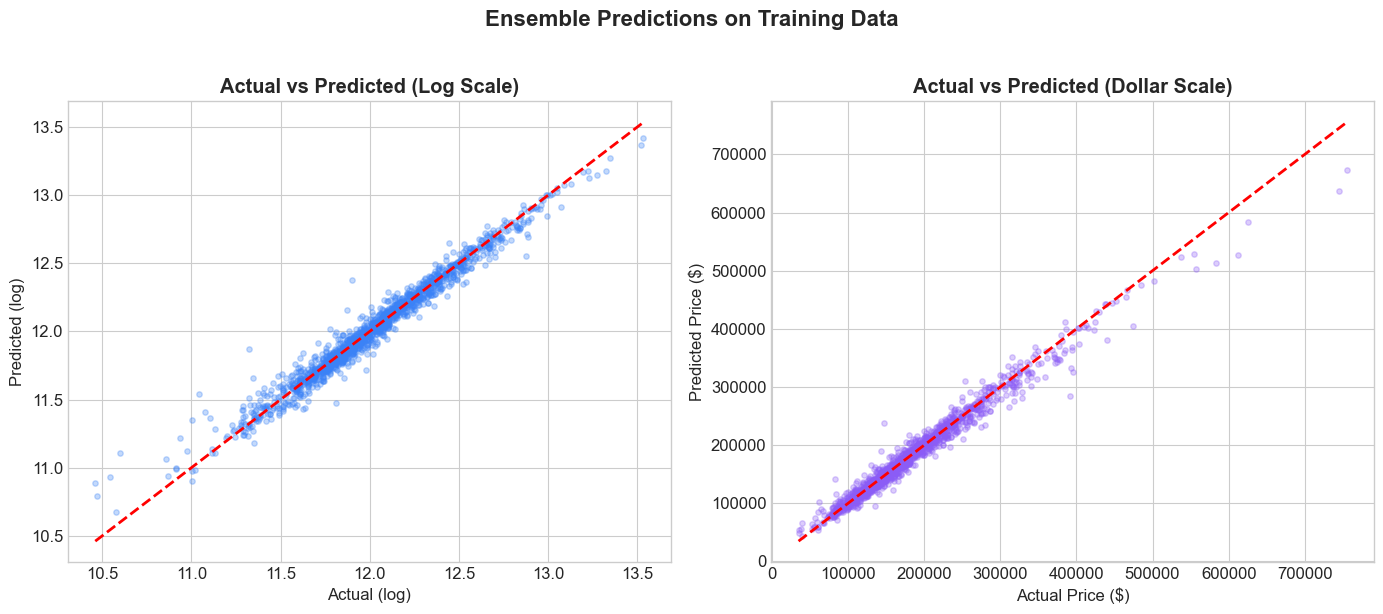

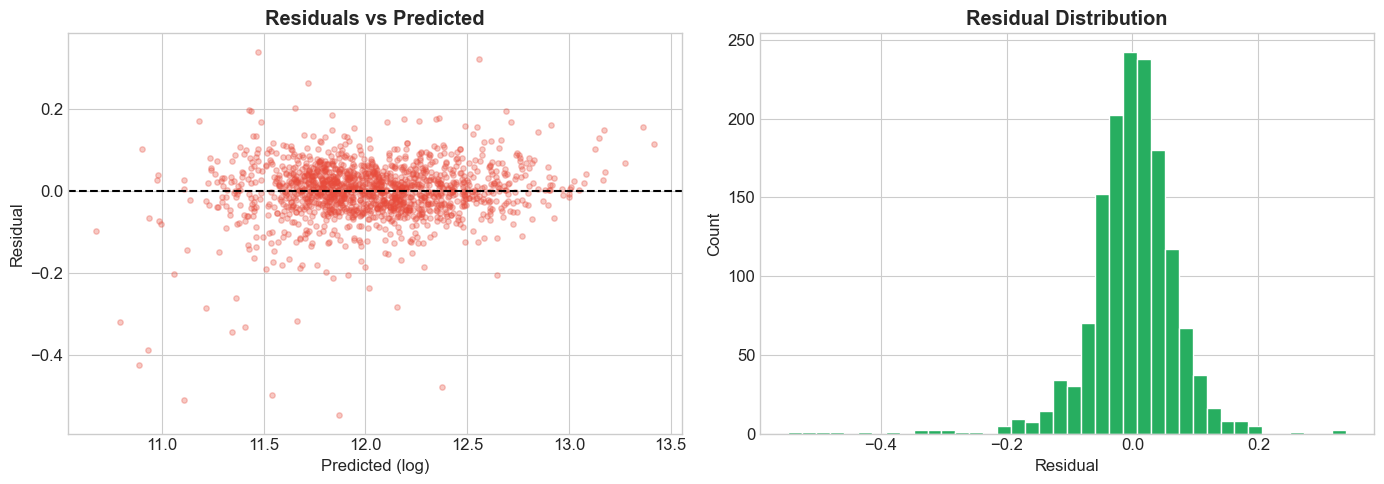

In [21]:
# Actual vs Predicted on training data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log scale
axes[0].scatter(y, ensemble_train, alpha=0.3, color='#3B82F6', s=15)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual (log)')
axes[0].set_ylabel('Predicted (log)')
axes[0].set_title('Actual vs Predicted (Log Scale)', fontweight='bold')

# Dollar scale
actual_dollars = np.expm1(y)
predicted_dollars = np.expm1(ensemble_train)
axes[1].scatter(actual_dollars, predicted_dollars, alpha=0.3, color='#8B5CF6', s=15)
axes[1].plot([actual_dollars.min(), actual_dollars.max()],
             [actual_dollars.min(), actual_dollars.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Actual vs Predicted (Dollar Scale)', fontweight='bold')

plt.suptitle('Ensemble Predictions on Training Data', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Residual analysis
residuals = y - ensemble_train
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ensemble_train, residuals, alpha=0.3, color='#E74C3C', s=15)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted (log)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=40, color='#27AE60', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

---
### Step 18: Output File 

In [22]:
# Inverse log transform to get dollar prices
final_predictions = np.expm1(ensemble_pred)

# Create submission file
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file created: submission.csv")
print(f"\nPrediction summary:")
print(f"  Mean:   ${final_predictions.mean():,.0f}")
print(f"  Median: ${np.median(final_predictions):,.0f}")
print(f"  Min:    ${final_predictions.min():,.0f}")
print(f"  Max:    ${final_predictions.max():,.0f}")

print(f"\nOutputFile Generated")

# Show first few predictions
print(f"\nFirst 5 predictions:")
print(submission.head().to_string(index=False))

Submission file created: submission.csv

Prediction summary:
  Mean:   $178,304
  Median: $156,915
  Min:    $50,495
  Max:    $764,150

OutputFile Generated

First 5 predictions:
  Id     SalePrice
1461 118679.757351
1462 157581.165569
1463 183946.286749
1464 201175.779726
1465 191309.024660


---
### Step 19: Summary & Key Takeaways

In [23]:
print("="*35)
print("           FINAL RESULTS")
print("="*35)
print(f"""
MODEL COMPARISON (5-Fold CV RMSE- lower is better):

| Model      | CV RMSE  | Notes                                |
|------------|----------|--------------------------------------|
| Ridge      | {ridge_mean:.4f}   | L2 regularization, alpha=10          |
| Lasso      | {lasso_mean:.4f}   | L1, eliminates weak features          |
| ElasticNet | {enet_mean:.4f}   | L1+L2 hybrid                         |
| GBR        | {gbr_mean:.4f}   | Gradient Boosting, 500 trees          |
| XGBoost    | {xgb_mean:.4f}   | Regularized boosting                  |
| LightGBM   | {lgb_mean:.4f}   | Fast gradient boosting                |
| ENSEMBLE   | {ensemble_rmse:.4f}   | Weighted average of all 6             |

KEY TAKEAWAYS:

1. Log-transforming SalePrice was the single biggest improvement :
   it turned a right-skewed target into a near-normal distribution.

2. Feature engineering (TotalSF, TotalBath, HouseAge, etc.) added
   meaningful signal that raw features couldn't express alone.

3. Context-aware missing value handling (NaN = "no garage", not missing)
   preserved important information instead of blindly imputing.

4. The weighted ensemble outperforms any individual model by exploiting
   the fact that different models make different types of errors.

5. Lasso's feature selection identified the most important predictors
   and eliminated {(lasso.coef_ == 0).sum()} weak features automatically.

6. OverallQual, GrLivArea, and TotalSF are the strongest predictors
   of house prices quality and size matter most.
""")

           FINAL RESULTS

MODEL COMPARISON (5-Fold CV RMSE- lower is better):

| Model      | CV RMSE  | Notes                                |
|------------|----------|--------------------------------------|
| Ridge      | 0.1147   | L2 regularization, alpha=10          |
| Lasso      | 0.1141   | L1, eliminates weak features          |
| ElasticNet | 0.1143   | L1+L2 hybrid                         |
| GBR        | 0.1158   | Gradient Boosting, 500 trees          |
| XGBoost    | 0.1187   | Regularized boosting                  |
| LightGBM   | 0.1201   | Fast gradient boosting                |
| ENSEMBLE   | 0.0715   | Weighted average of all 6             |

KEY TAKEAWAYS:

1. Log-transforming SalePrice was the single biggest improvement :
   it turned a right-skewed target into a near-normal distribution.

2. Feature engineering (TotalSF, TotalBath, HouseAge, etc.) added
   meaningful signal that raw features couldn't express alone.

3. Context-aware missing value handling (NaN = "